<a href="https://colab.research.google.com/github/AviramNisimyan/22961-Maman14/blob/main/Aviram_Nisimyan_206400178_Maman14_22961.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aviram Nisimyan, 206400178, Maman 14 ,Deep Learning 22961**

# **Question 1:**

## **Importing:**

In [1]:
import torch
import torch.nn as nn

## **Questions 1.1 ּ+ 1.2:**

In [2]:
class SplitLinear(nn.Module):
    def __init__(self, in_features):
        super().__init__()

        # Assuming in_features (M) is even according to the instructions.
        # The split halves will have M // 2 features each.
        self.linear = nn.Linear(in_features // 2, in_features // 2)

        # Explicitly initialize the weights
        # We use Kaiming Uniform initialization because it is highly recommended
        # for layers followed by a ReLU activation function (prevents vanishing gradients).
        nn.init.kaiming_uniform_(self.linear.weight, nonlinearity='relu')

        # Initialize biases to zero
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):

        # 1. Split the input tensor into two equal halves along the feature dimension (dim=1)
        x1, x2 = torch.tensor_split(x, 2, dim=1)

        # 2. Pass both halves through the EXACT SAME linear layer (Shared Weights)
        out1 = self.linear(x1)
        out2 = self.linear(x2)

        # 3. Apply ReLU activation to both halves
        out1 = torch.relu(out1)
        out2 = torch.relu(out2)

        # 4. Concatenate the halves back together in their original order
        # The output dimension will be identical to the original input (N x M)
        out = torch.cat([out1, out2], dim=1)

        return out

## **Questions 1.3:**

In [3]:
torch.manual_seed(0)
N = 3  # Batch size
M = 6  # Number of features
layer = SplitLinear(M)
x = torch.randn(N, M)
print(f"1. Original input (x) shape {x.shape}:\n{x}\n")

# Split along the feature dimension
x1, x2 = torch.tensor_split(x, 2, dim=1)
print(f"2. Split x1 shape {x1.shape}:\n{x1}\n")
print(f"2. Split x2 shape {x2.shape}:\n{x2}\n")

# Shared linear layer
out1 = layer.linear(x1)
out2 = layer.linear(x2)
print(f"3. linear(x1):\n{out1}\n")
print(f"3. linear(x2):\n{out2}\n")

# ReLU activation
out1 = torch.relu(out1)
out2 = torch.relu(out2)
print(f"4. relu on first half:\n{out1}\n")
print(f"4. relu on second half:\n{out2}\n")

# Concatenate -> final output
out = torch.cat((out1, out2), dim=1)
print(f"5. output y {out.shape}:\n{out}")


1. Original input (x) shape torch.Size([3, 6]):
tensor([[-1.5551, -0.3414,  0.4412, -0.2159, -0.7425,  0.5627],
        [ 0.2596, -0.1740, -0.6787,  0.9383, -1.5867,  1.2032],
        [ 0.0845, -1.2001, -0.0048, -0.5181, -0.3067, -1.5810]])

2. Split x1 shape torch.Size([3, 3]):
tensor([[-1.5551, -0.3414,  0.4412],
        [ 0.2596, -0.1740, -0.6787],
        [ 0.0845, -1.2001, -0.0048]])

2. Split x2 shape torch.Size([3, 3]):
tensor([[-0.2159, -0.7425,  0.5627],
        [ 0.9383, -1.5867,  1.2032],
        [-0.5181, -0.3067, -1.5810]])

3. linear(x1):
tensor([[ 2.1636,  0.1020,  1.9278],
        [ 0.2078, -0.6596, -0.4904],
        [ 1.0126, -0.6706,  0.6556]], grad_fn=<AddmmBackward0>)

3. linear(x2):
tensor([[ 0.6591,  0.0510,  0.9533],
        [-0.4830,  0.1831,  0.6956],
        [ 1.9089, -1.5402, -0.1265]], grad_fn=<AddmmBackward0>)

4. relu on first half:
tensor([[2.1636, 0.1020, 1.9278],
        [0.2078, 0.0000, 0.0000],
        [1.0126, 0.0000, 0.6556]], grad_fn=<ReluBackward0

## **Questions 1.4:**

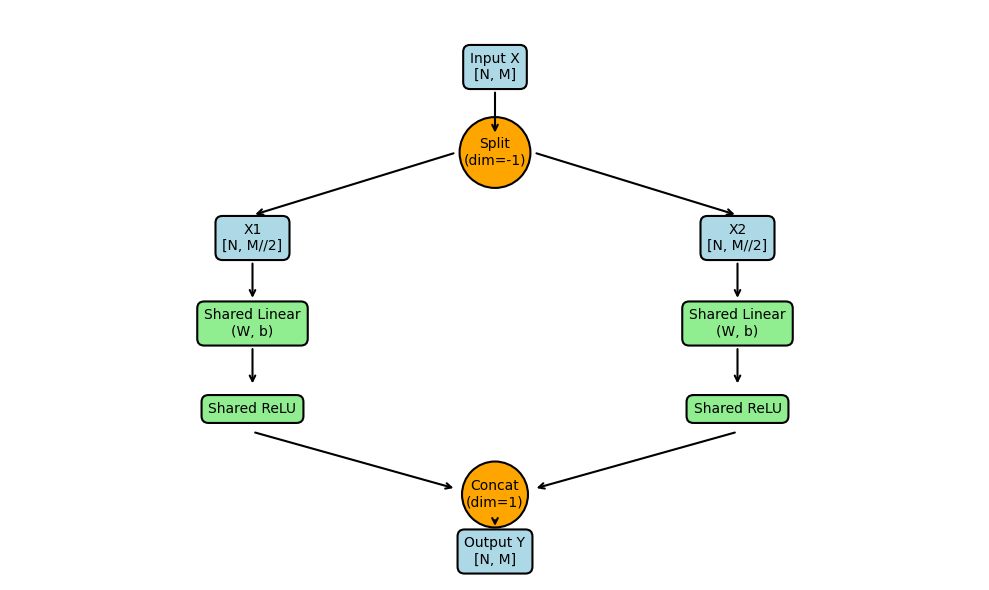

## **Questions 1.5:**

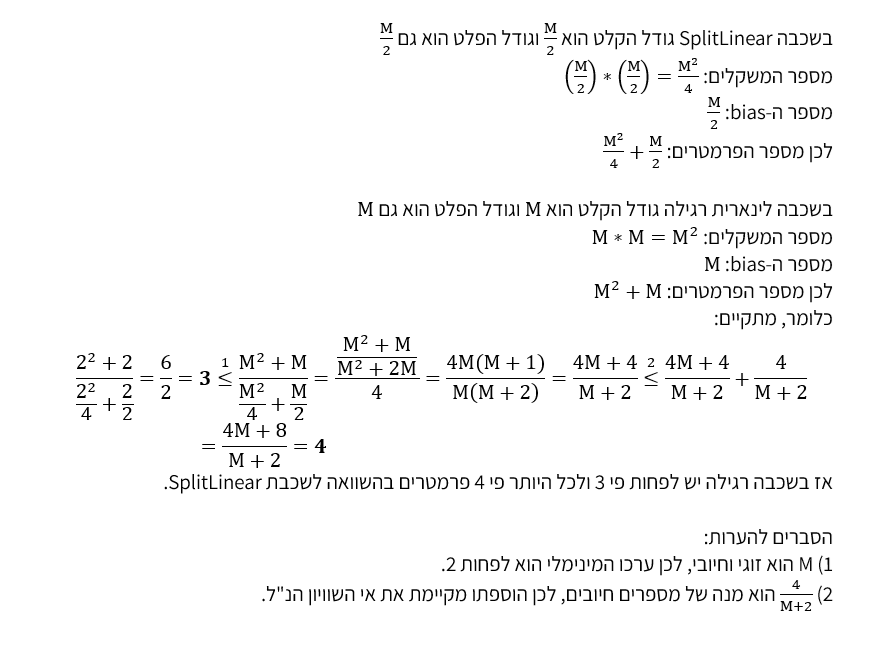

## **Questions 1.6:**

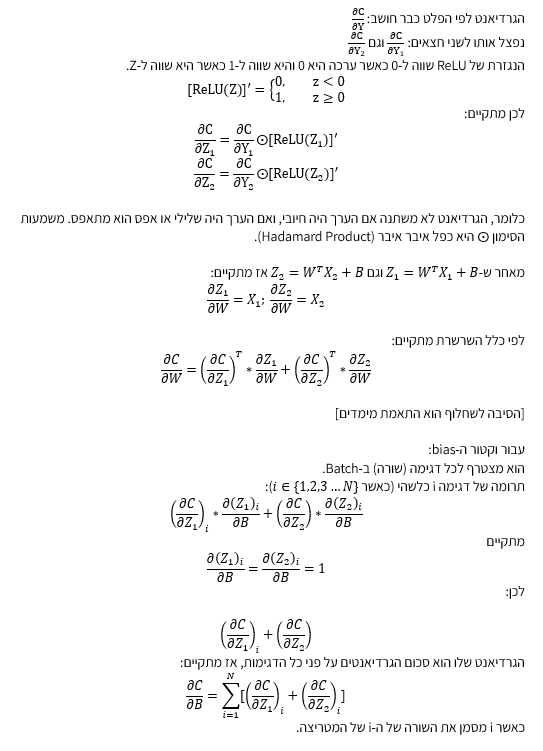

## **Questions 1.7:**

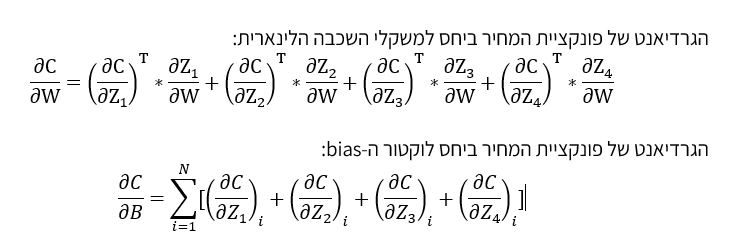

# **Question 2:**

## **Importing:**

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

## **Questions 2.1 + 2.2 + 2.3:**

In [5]:
class DropNorm(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.num_features = num_features
        self.eps = eps

        # Learnable parameters (gamma and beta), initialized to 1 and 0 respectively.
        # Each feature gets its own pair of parameters.
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))

    def forward(self, x):
        if self.training:
            # --- TRAINING MODE ---

            # 1. Create a mask to randomly select exactly half of the features.
            # The mask shape is (1, M) to ensure the EXACT SAME features are chosen
            # for all samples in the current batch (broadcasting will handle the batch size N).
            mask = torch.zeros(1, self.num_features, device=x.device)

            # Randomly select M // 2 indices to KEEP
            keep_indices = torch.randperm(self.num_features)[:self.num_features // 2]
            mask[0, keep_indices] = 1

            # 2. Zero out half of the features
            masked_x = x * mask

            # 3. Calculate mean and variance ONLY over the features that were NOT zeroed out.
            # We slice the tensor to extract only the valid (kept) features for statistics.
            kept_features = x[..., keep_indices]

            # Compute mean and variance along the feature dimension.
            # keepdim=True allows broadcasting back to the original shape (N x M).
            mu = kept_features.mean(dim=-1, keepdim=True)
            var = kept_features.var(dim=-1, unbiased=False, keepdim=True)

            # Normalize the entire input tensor using the stats of the kept features
            x_hat = (x - mu) / torch.sqrt(var + self.eps)

            # 4. Apply the learnable affine parameters (gamma and beta)
            y = self.gamma * x_hat + self.beta

            # Ensure the dropped features remain exactly 0 after applying beta
            y = y * mask

        else:
            # --- PREDICTION MODE (EVAL) ---

            # During evaluation, Dropout is usually disabled (no features are zeroed out).
            # We calculate the mean and variance over ALL features for each sample.
            mu = x.mean(dim=-1, keepdim=True)
            var = x.var(dim=-1, unbiased=False, keepdim=True)

            # Normalize using the statistics of the entire feature set
            x_hat = (x - mu) / torch.sqrt(var + self.eps)

            # Apply learnable parameters
            y = self.gamma * x_hat + self.beta

            # Note: Standard dropout requires scaling weights during eval,
            # but since we normalize the data per-sample here (similar to LayerNorm),
            # the variance inherently adapts, making manual scaling unnecessary.

        return y

## **Question 2.4:**

In [6]:
# Set device to GPU (CUDA) if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define hyperparameters
batch_size = 64
learning_rate = 0.001
num_epochs = 10

# ==========================================
# 2. Data Preparation (Fashion-MNIST)
# ==========================================
# Transform to convert PIL images to PyTorch Tensors and scale values to [0, 1]
transform = transforms.ToTensor()

# Download and load the training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True
)
# Download and load the testing dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True
)

# Create DataLoaders to iterate through the datasets in batches
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# ==========================================
# 3. Model Definition (Using built-in layers)
# ==========================================
class StandardNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 28*28 = 784 features (Fashion MNIST image dimensions)
        self.fc1 = nn.Linear(28 * 28, 256)

        # Using PyTorch's built-in layers as required
        self.bn1 = nn.BatchNorm1d(256)
        self.drop = nn.Dropout(0.5)

        # Output layer: 10 classes corresponding to the different clothing items
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # Flatten the image from [Batch, 1, 28, 28] to a 2D tensor [Batch, 784]
        flat_input = x.reshape(x.shape[0], -1)

        # Forward pass through the linear layer, batch normalization, and ReLU activation
        hidden = torch.relu(self.bn1(self.fc1(flat_input)))

        # Apply the built-in Dropout layer to prevent overfitting
        dropped_hidden = self.drop(hidden)

        # Output layer (No Softmax activation here because CrossEntropyLoss applies it internally)
        output = self.fc2(dropped_hidden)
        return output

# Instantiate the model and move it to the configured device (GPU or CPU)
model = StandardNet().to(device)

# ==========================================
# 4. Loss Function and Optimizer
# ==========================================
# CrossEntropyLoss is used for multi-class classification tasks
criterion = nn.CrossEntropyLoss()
# Adam optimizer for updating model parameters based on computed gradients
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ==========================================
# 5. Training Loop
# ==========================================
print("Starting training...")

for epoch in range(num_epochs):
    # Set the model to training mode (enables Dropout and tracks BatchNorm statistics)
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        # Move data tensors to the active device
        images = images.to(device)
        labels = labels.to(device)

        # Clear the gradients of all optimized variables from the previous step
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # Perform a single optimization step (parameter update)
        optimizer.step()

        # Calculate training metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Calculate average loss and accuracy for the current epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct_train / total_train

    # --- Evaluation Phase (Validation/Testing) at the end of each Epoch ---
    # Set the model to evaluation mode (disables Dropout, uses global statistics for BatchNorm)
    model.eval()
    correct_test = 0
    total_test = 0

    # Disable gradient calculation to reduce memory usage and speed up computations
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    # Calculate testing accuracy
    test_acc = correct_test / total_test

    # Print epoch statistics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")

print("Training finished.")

Using device: cuda
Starting training...
Epoch [1/10] | Train Loss: 0.5192 | Train Acc: 0.8158 | Test Acc: 0.8419
Epoch [2/10] | Train Loss: 0.4199 | Train Acc: 0.8485 | Test Acc: 0.8564
Epoch [3/10] | Train Loss: 0.3856 | Train Acc: 0.8612 | Test Acc: 0.8600
Epoch [4/10] | Train Loss: 0.3686 | Train Acc: 0.8662 | Test Acc: 0.8629
Epoch [5/10] | Train Loss: 0.3515 | Train Acc: 0.8719 | Test Acc: 0.8701
Epoch [6/10] | Train Loss: 0.3428 | Train Acc: 0.8738 | Test Acc: 0.8722
Epoch [7/10] | Train Loss: 0.3299 | Train Acc: 0.8800 | Test Acc: 0.8800
Epoch [8/10] | Train Loss: 0.3223 | Train Acc: 0.8813 | Test Acc: 0.8812
Epoch [9/10] | Train Loss: 0.3160 | Train Acc: 0.8824 | Test Acc: 0.8797
Epoch [10/10] | Train Loss: 0.3098 | Train Acc: 0.8861 | Test Acc: 0.8807
Training finished.


## **Question 2.5:**

In [7]:
class CustomNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 28*28 = 784 features (Fashion MNIST flattened image dimensions)
        self.fc1 = nn.Linear(28 * 28, 256)

        # Using our custom DropNorm layer instead of BatchNorm + Dropout
        self.dropnorm = DropNorm(num_features=256)

        # Output layer: 10 classes corresponding to the clothing items
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # Flatten the input image from [Batch, 1, 28, 28] to [Batch, 784]
        flat_input = x.reshape(x.shape[0], -1)

        # Forward pass through the first linear layer, then our custom DropNorm
        hidden = self.dropnorm(self.fc1(flat_input))

        # Apply ReLU activation AFTER the normalization
        activated_hidden = torch.relu(hidden)

        # Output layer (CrossEntropyLoss applies Softmax internally)
        output = self.fc2(activated_hidden)
        return output

# Instantiate the custom model and move it to the configured device (GPU/CPU)
custom_model = CustomNet().to(device)

# New optimizer for the custom model (criterion is reused from section 2.4)
custom_optimizer = optim.Adam(custom_model.parameters(), lr=learning_rate)

# ==============================================================================
# Training Loop for CustomNet
# ==============================================================================
print("Starting training for CustomNet with DropNorm...")

for epoch in range(num_epochs):
    # Set the model to training mode (enables the dropping mechanism in DropNorm)
    custom_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        # Move data tensors to the active device
        images = images.to(device)
        labels = labels.to(device)

        # Clear the gradients from the previous step
        custom_optimizer.zero_grad()

        # Forward pass
        outputs = custom_model(images)
        loss = criterion(outputs, labels)

        # Backward pass: compute gradient and update parameters
        loss.backward()
        custom_optimizer.step()

        # Calculate training metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # Calculate average loss and accuracy for the current epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct_train / total_train

    # --- Evaluation Phase (Validation/Testing) ---
    # Set the model to evaluation mode (disables dropping, uses global stats in DropNorm)
    custom_model.eval()
    correct_test = 0
    total_test = 0

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = custom_model(images)
            _, predicted = torch.max(outputs.data, 1)

            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    # Calculate testing accuracy
    test_acc = correct_test / total_test

    # Print epoch statistics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | "
          f"Test Acc: {test_acc:.4f}")

print("Training for CustomNet finished.")

Starting training for CustomNet with DropNorm...
Epoch [1/10] | Train Loss: 0.6009 | Train Acc: 0.7916 | Test Acc: 0.8402
Epoch [2/10] | Train Loss: 0.4447 | Train Acc: 0.8396 | Test Acc: 0.8516
Epoch [3/10] | Train Loss: 0.4099 | Train Acc: 0.8498 | Test Acc: 0.8574
Epoch [4/10] | Train Loss: 0.3907 | Train Acc: 0.8574 | Test Acc: 0.8585
Epoch [5/10] | Train Loss: 0.3737 | Train Acc: 0.8637 | Test Acc: 0.8617
Epoch [6/10] | Train Loss: 0.3612 | Train Acc: 0.8676 | Test Acc: 0.8715
Epoch [7/10] | Train Loss: 0.3516 | Train Acc: 0.8718 | Test Acc: 0.8718
Epoch [8/10] | Train Loss: 0.3426 | Train Acc: 0.8744 | Test Acc: 0.8718
Epoch [9/10] | Train Loss: 0.3321 | Train Acc: 0.8784 | Test Acc: 0.8732
Epoch [10/10] | Train Loss: 0.3301 | Train Acc: 0.8778 | Test Acc: 0.8765
Training for CustomNet finished.


## **Question 2.6:**

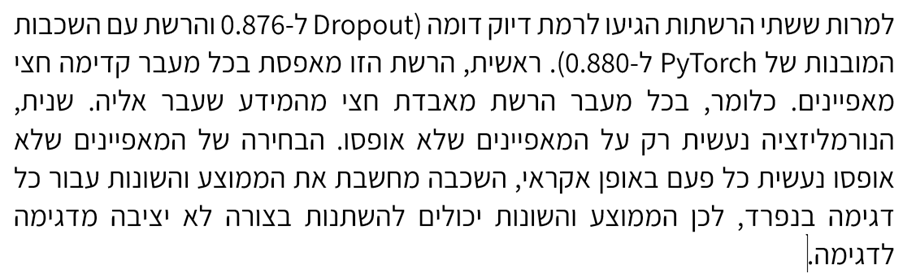

## **Question 2.7:**

הפתרון בקובץ וורד